In [1]:
import time
import functools
import numpy as np
import numdifftools as nd
import matplotlib.pyplot as plt
from scipy import integrate, optimize

 - https://stackoverflow.com/questions/68266571/how-to-speed-up-the-ipopt-solver

In [2]:
n = 121
t = np.linspace(0, 12, n)
dt = t[1] - t[0]

In [3]:
x0 = np.array([
    0.5 * np.ones(shape=(n,)),
    0.7 * np.ones(shape=(n,)),
    np.zeros(shape=(n,)),
])

In [4]:
bounds = np.array([
    [(0.5, 0.5)] + [(-np.inf, +np.inf)] * (n - 1),
    [(0.7, 0.7)] + [(-np.inf, +np.inf)] * (n - 1),
    [(0., 1.)] * n,
])

In [5]:
def integrand(x):
    x1, x2, v = x.reshape(3, -1)
    return (x1 - 1.) ** 2 + (x2 - 1.) ** 2

In [6]:
def integral(x, dt):
    return integrate.trapezoid(y=integrand(x), dx=dt)

In [7]:
def constraint1(x, dt):
    x1, x2, v = x.reshape(3, -1)
    return + x1 - x1 * x2 - 0.4 * x1 * v - np.gradient(x1, dt)

In [8]:
def constraint2(x, dt):
    x1, x2, v = x.reshape(3, -1)
    return - x2 + x1 * x2 - 0.2 * x2 * v - np.gradient(x2, dt)

In [13]:
start = time.time()
solution = optimize.minimize(
    method='SLSQP',
    fun=functools.partial(integral, dt=dt),
    x0=x0.ravel(),
    bounds=bounds.ravel().reshape(-1, 2),
    constraints=(
        optimize.NonlinearConstraint(functools.partial(constraint1, dt=dt), lb=0, ub=0),
        optimize.NonlinearConstraint(functools.partial(constraint2, dt=dt), lb=0, ub=0)
    ),
)
stop = time.time()

In [14]:
solution

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 1.3482596367630841
       x: [ 5.000e-01  5.150e-01 ...  8.210e-03  6.814e-03]
     nit: 51
     jac: [       nan -9.700e-02 ...  0.000e+00  0.000e+00]
    nfev: 18465
    njev: 51

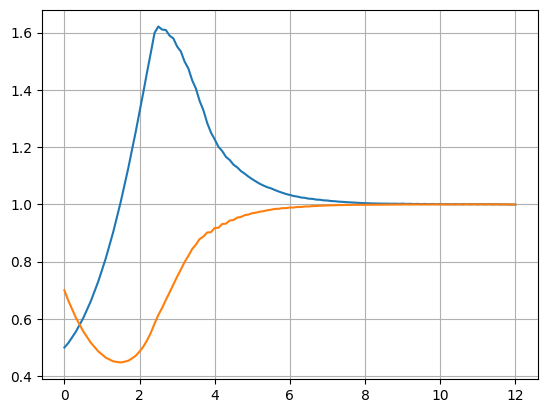

In [15]:
fig, axe = plt.subplots()
axe.plot(t, solution.x.reshape(3, -1).T[:,:2])
axe.grid()